In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('superstore_data.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(9800, 18)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156  2017-11-08  2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688  2017-06-12  2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966  2016-10-11  2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States 

# Region-Wise Sales

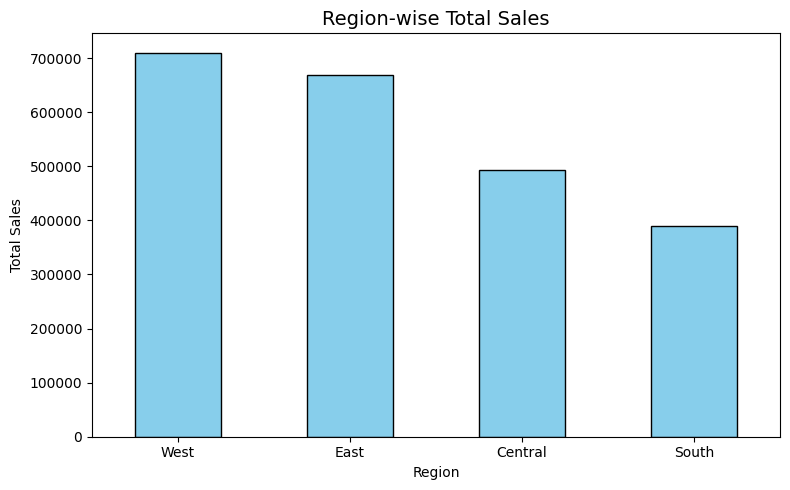

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [2]:
# Region-wise total sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Region-wise Total Sales', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(region_sales)

# Category-wise Sales

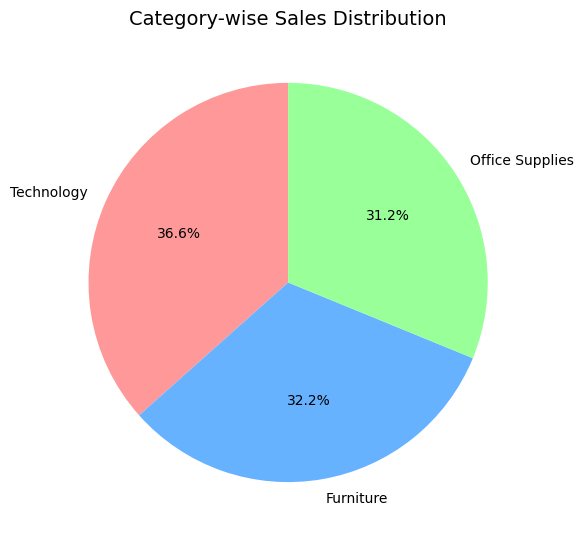

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [3]:
# Category-wise Total Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%',
        colors=['#FF9999', '#66B2FF', '#99ff99'],
        startangle=90)
plt.title('Category-wise Sales Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(category_sales)

# Top 10 Products

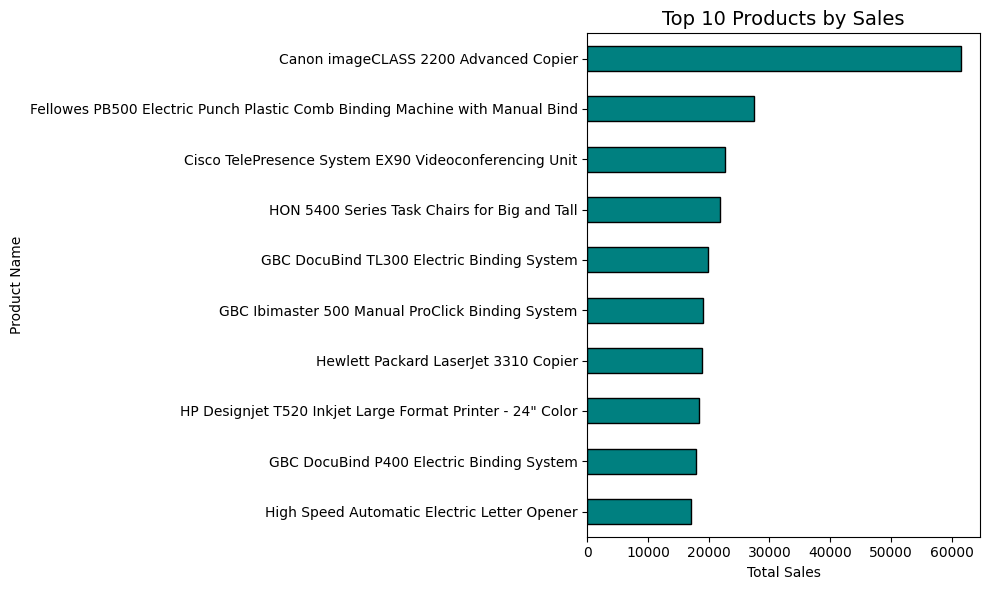

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [4]:
# Top 10 products by Sales
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Products by Sales', fontsize=14)
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_products)
           

# Monthly Sales Trend

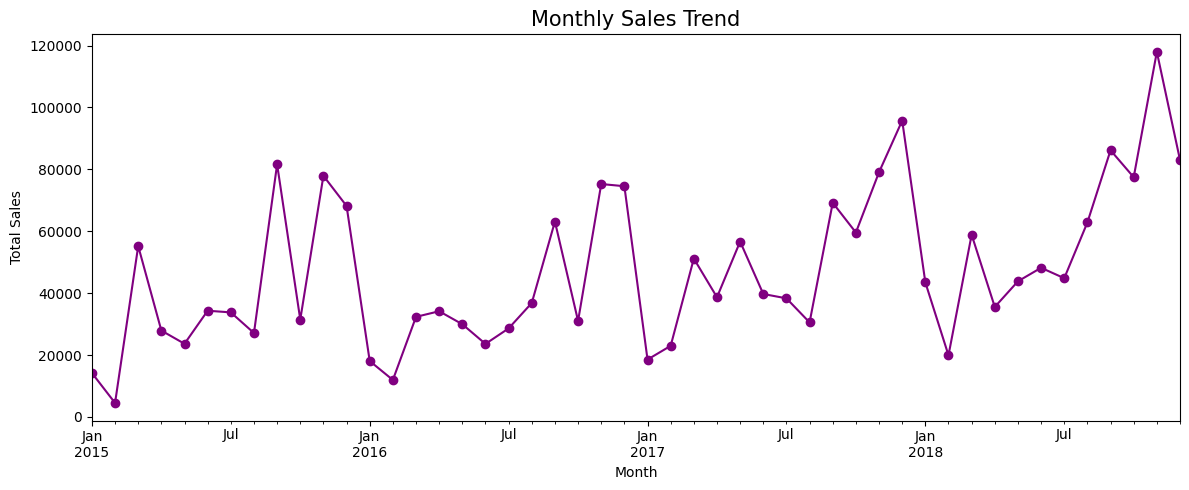

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trend', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
                 


# Segment-wise Sales

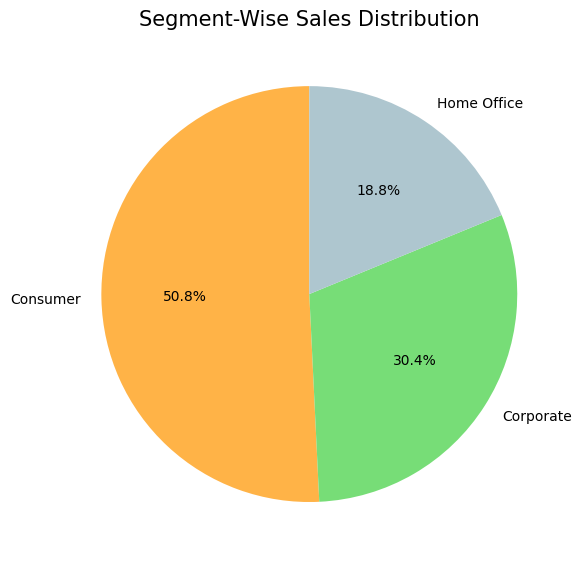

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [6]:
# Segment-wise Sales
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(6,6))
plt.pie(segment_sales,
        labels=segment_sales.index,
        autopct='%1.1F%%',
        colors=['#FFB347','#77DD77','#AEC6CF'],
        startangle=90)
plt.title('Segment-Wise Sales Distribution', fontsize=15)
plt.tight_layout()
plt.show()

print(segment_sales)                                                   

# Ship Mode Usage 

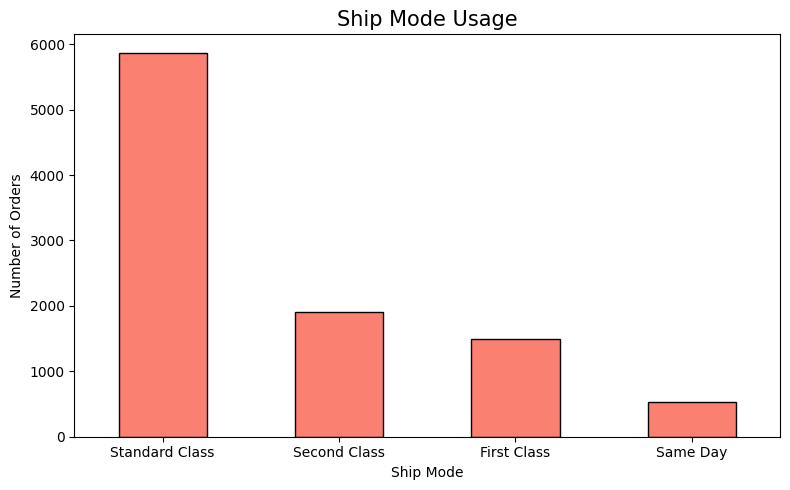

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


In [7]:
# Ship Mode Wise Count
ship_mode = df['Ship Mode'].value_counts()

plt.figure(figsize=(8,5))
ship_mode.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Ship Mode Usage', fontsize=15)
plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(ship_mode)

# Overview Dashboard

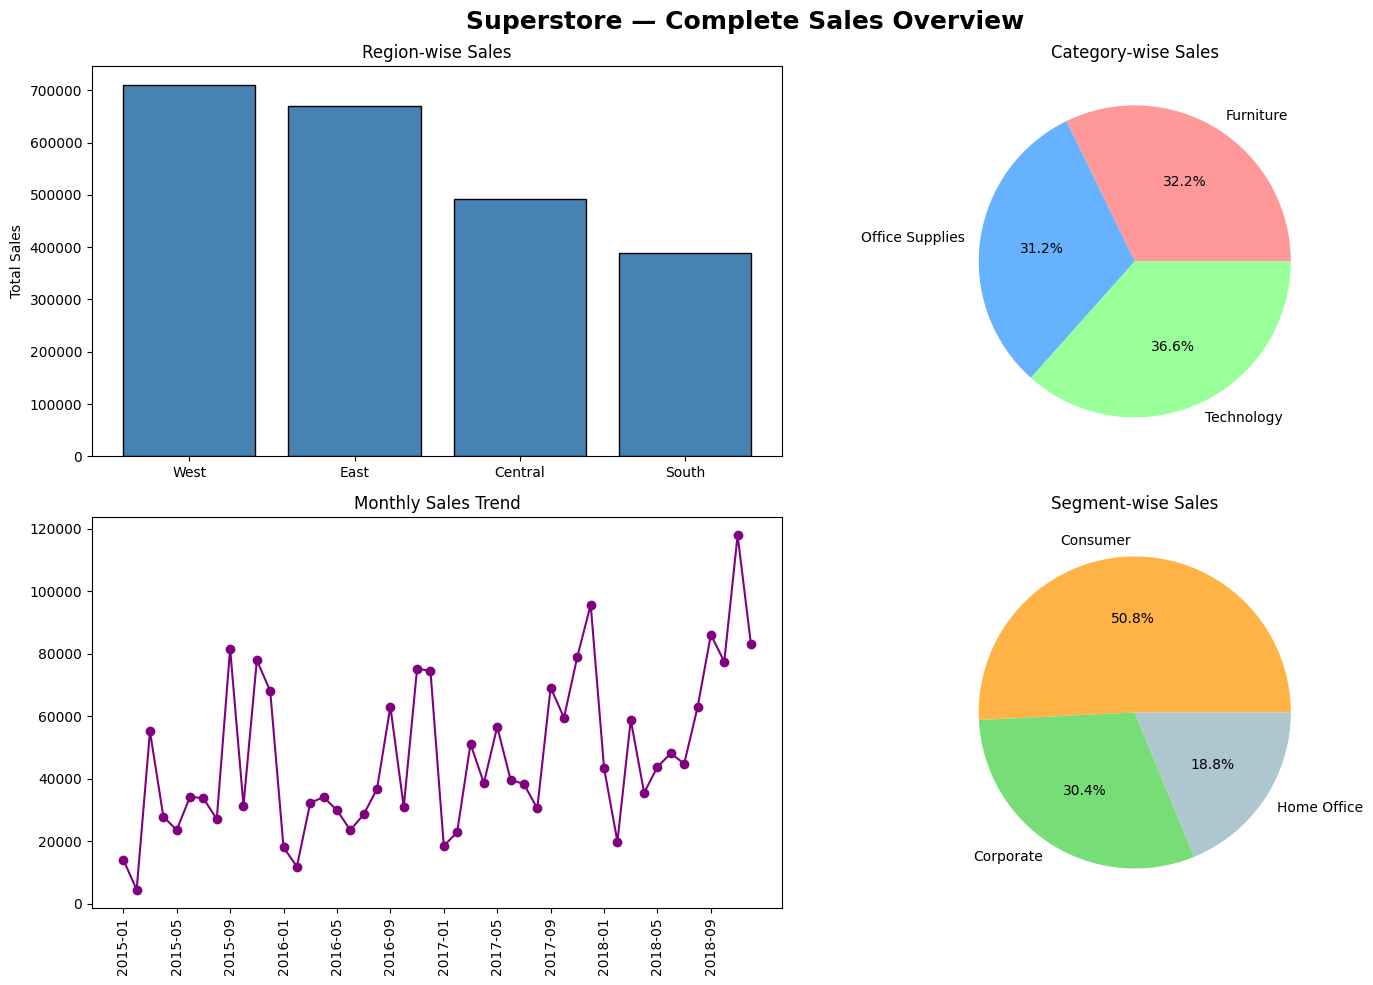

In [8]:
# Complete Dataset Overview - 4 charts in one figure
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Region-wise Sales
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0,0].bar(region_sales.index, region_sales.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Region-wise Sales')
axes[0,0].set_ylabel('Total Sales')

# 2. Category-wise Sales
category_sales = df.groupby('Category')['Sales'].sum()
axes[0,1].pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', colors=['#FF9999','#66B2FF','#99FF99'])
axes[0,1].set_title('Category-wise Sales')

# 3. Monthly Trend
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
axes[1,0].plot(monthly_sales.index.astype(str), monthly_sales.values, color='purple', marker='o')
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_xticks(axes[1,0].get_xticks()[::4])  # har 4th label dikhao

# 4. Segment-wise Sales
segment_sales = df.groupby('Segment')['Sales'].sum()
axes[1,1].pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%', colors=['#FFB347','#77DD77','#AEC6CF'])
axes[1,1].set_title('Segment-wise Sales')

plt.suptitle('Superstore — Complete Sales Overview', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()